## DATA PREPROCESSING FOR MODELING

## I. Tổng quan về dữ liệu thô

### 1. Tải thư viện & đọc file

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from pathlib import Path
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
path = "../data/amazon_crawl/amazon_products_US_20260324_231228.csv"
try:
    df = pd.read_csv(path)
    print("Tải dữ liệu thành công")
except Exception as e:
    print(f"Tải dữ liệu thất bại: {e}")

Tải dữ liệu thành công


### 2. Thông tin cơ bản

In [3]:
df.head()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
0,B08NHSPCR6,HP Chromebook 11A G8 Education Edition AMD A4-...,NaN,NaN,4.1,1161,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B0GR6F8HXV,Apple 2026 MacBook Neo 13-inch Laptop with A18...,749.00,NaN,4.8,73,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0D7NVS6RV,"Lenovo Yoga 7i 2-in-1 Laptop, 16&quot; 2K Touc...",799.99,NaN,4.5,167,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08H5878D3,LEXiBOOK Spider-Man - Educational and Bilingua...,49.99,NaN,4.2,1355,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B0791H74NT,Creative Pebble 2.0 USB-Powered Desktop Speake...,23.74,24.99,4.5,67192,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
9175,B086P8YGYW,L&#x27;ANGE HAIR Le Vite Straightening Brush |...,39.00,NaN,4.3,9652,USD,True,True,False,...,https://m.media-amazon.com/images/I/51ZBnaDgA8...,True,[],NaN,{'Product Benefits': 'Adjustable temperature r...,{'Product Dimensions': '13.74 x 2.24 x 4.41 in...,True,['https://m.media-amazon.com/images/S/aplus-me...,True,"[{'name': ""This item: L'ANGE HAIR Le Vite Str..."
9176,B09MYSWLGT,"SUNHZMCKP Magnetic Screwdriver Set 66-Piece, S...",39.99,NaN,4.7,2759,USD,True,True,False,...,https://m.media-amazon.com/images/I/81vbZh2aDd...,True,['【TOP MATERIALS】: Professional screwdriver ki...,NaN,"{'Brand Name': 'SUNHZ MCKP', 'Manufacturer': '...","{'Brand': 'SUNHZ MCKP', 'Color': 'Blue, Yellow...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[]
9177,B087G6TGJL,Fathers Day Dad Gifts from Daughter Son Wife S...,9.49,9.99,4.5,21528,USD,True,False,False,...,https://m.media-amazon.com/images/I/51S61p7TfC...,True,['The One Tool Can Replace The Whole Set: Focu...,NaN,"{'Head Style': 'Flat', 'Operation Mode': 'Pneu...","{'Color': 'Silver', 'Brand': 'HANPURE', 'Mater...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[{'name': 'This item: Fathers Day Dad Gifts f...
9178,B08HQ59Q91,"HYCHIKA Detail Sander, 14,000 OPM Compact Elec...",22.96,25.51,4.4,1951,USD,True,True,False,...,https://m.media-amazon.com/images/I/51mRT3QvrQ...,True,['🍀[Quiet and Efficient] - HYCHIKA detail sand...,NaN,"{'Voltage': '120 Volts (AC)', 'Power Source': ...",{'Brand': 'HYCHIKA BETTER TOOLS FOR BETTER LIF...,True,['https://m.media-amazon.com/images/S/aplus-me...,True,"[{'name': 'This item: HYCHIKA Detail Sander, ..."
9179,B07WDJ8Q79,44pcs Cutting Wheel Set Compatible with Plasti...,9.99,NaN,4.4,13545,USD,True,False,False,...,NaN,False,['RESIN CUT OFF DISCS – With low heat generati...,NaN,"{'Material Type': 'Plastic,Resin', 'Grit Mater...","{'Grit Material': 'Diamond', 'Product Dimensio...",True,['https://m.media-amazon.com/images/S/aplus-me...,True,[{'name': 'This item: 44pcs Cutting Wheel Set...


#### 2.1. Kích thước dữ liệu

In [5]:
print(f"Data shape: {df.shape}")

num_rows, num_columns = df.shape
print(f"Số dòng: {num_rows}")
print(f"Số cột: {num_columns}")

Data shape: (9180, 58)
Số dòng: 9180
Số cột: 58


#### 2.2. Kiểu dữ liệu của các đặc trưng

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asin                        9180 non-null   object 
 1   title                       9180 non-null   object 
 2   price                       8910 non-null   float64
 3   original_price              4096 non-null   float64
 4   rating                      9157 non-null   float64
 5   reviews                     9180 non-null   int64  
 6   currency                    8939 non-null   object 
 7   is_best_seller              9180 non-null   bool   
 8   is_amazon_choice            9180 non-null   bool   
 9   is_prime                    9180 non-null   bool   
 10  sales_volume                8308 non-null   object 
 11  main_category               9180 non-null   object 
 12  category_hierarchy          9180 non-null   object 
 13  crawl_category              9180 

#### 2.3. Ý nghĩa của các đặc trưng

| STT | Feature | Đơn vị | Ý nghĩa |
|-----|--------|-------|--------|
| 1 | asin | Không có | Mã định danh duy nhất của sản phẩm trên Amazon (ASIN). |
| 2 | title | Không có | Tiêu đề sản phẩm hiển thị trên Amazon, chứa thông tin mô tả chính. |
| 3 | price | USD ($) | Giá hiện tại của sản phẩm tại thời điểm crawl. |
| 4 | original_price | USD ($) | Giá gốc trước khi giảm giá (nếu có). |
| 5 | rating | Điểm (0–5) | Điểm đánh giá trung bình từ người dùng. |
| 6 | reviews | Số lượng | Tổng số lượt đánh giá (reviews) của sản phẩm. |
| 7 | currency | Không có | Đơn vị tiền tệ (ví dụ: USD). |
| 8 | is_best_seller | Boolean | Sản phẩm có thuộc danh sách Best Seller hay không. |
| 9 | is_amazon_choice | Boolean | Sản phẩm có được gắn nhãn “Amazon’s Choice” hay không. |
| 10 | is_prime | Boolean | Sản phẩm có hỗ trợ Amazon Prime hay không. |
| 11 | sales_volume | Không có | Số lượng bán ra (thường dạng text như “500+ bought”). |
| 12 | main_category | Không có | Danh mục chính của sản phẩm (ví dụ: electronics). |
| 13 | category_hierarchy | Không có | Cấu trúc phân cấp danh mục (dạng list hoặc JSON). |
| 14 | crawl_category | Không có | Danh mục dùng khi crawl dữ liệu. |
| 15 | link | URL | Đường dẫn đến trang sản phẩm. |
| 16 | image_url | URL | Đường dẫn đến ảnh chính của sản phẩm. |
| 17 | delivery_info | Không có | Thông tin giao hàng (thời gian, phí, khu vực). |
| 18 | number_of_offers | Số lượng | Số người bán cung cấp sản phẩm. |
| 19 | lowest_offer_price | USD ($) | Giá thấp nhất trong các offer. |
| 20 | has_variations | Boolean | Sản phẩm có nhiều biến thể hay không. |
| 21 | is_climate_friendly | Boolean | Sản phẩm có thân thiện môi trường hay không. |
| 22 | variation_dimensions | Không có | Các chiều biến thể (màu, size, cấu hình...). |
| 23 | variants | Không có | Thông tin các biến thể hiện tại. |
| 24 | all_variants | Không có | Danh sách toàn bộ biến thể của sản phẩm. |
| 25 | top_reviews | Không có | Các đánh giá nổi bật của sản phẩm. |
| 26 | detailed_rating | Không có | Phân bố rating chi tiết (5 sao, 4 sao...). |
| 27 | current_price | USD ($) | Giá hiện tại (có thể trùng với price). |
| 28 | product_name | Không có | Tên rút gọn của sản phẩm. |
| 29 | slug | Không có | Chuỗi định danh URL thân thiện (SEO). |
| 30 | parent_asin | Không có | ASIN của sản phẩm cha (nếu là biến thể). |
| 31 | landing_asin | Không có | ASIN trang landing chính. |
| 32 | brand_info | Không có | Thông tin thương hiệu. |
| 33 | brand_url | URL | Đường dẫn tới trang thương hiệu. |
| 34 | brand_urls | URL | Danh sách các URL liên quan đến brand. |
| 35 | unit_price | USD ($) | Giá trên mỗi đơn vị sản phẩm. |
| 36 | unit_count | Số lượng | Số lượng đơn vị trong sản phẩm. |
| 37 | min_order_quantity | Số lượng | Số lượng tối thiểu cần mua (hiện tại null). |
| 38 | country | Không có | Quốc gia bán hoặc phân phối sản phẩm. |
| 39 | availability | Không có | Tình trạng còn hàng. |
| 40 | condition | Không có | Tình trạng sản phẩm (new, used...). |
| 41 | estimated_delivery_date | Ngày | Ngày giao hàng dự kiến. |
| 42 | customer_feedback_summary | Không có | Tổng hợp phản hồi khách hàng (hiện null). |
| 43 | top_reviews_global | Không có | Review nổi bật toàn cầu. |
| 44 | is_bestseller | Không có | Cờ bestseller (phiên bản khác của is_best_seller). |
| 45 | main_image_url | URL | URL ảnh chính chi tiết. |
| 46 | additional_image_urls | URL | Danh sách ảnh bổ sung. |
| 47 | product_videos | Không có | Video chính thức của sản phẩm. |
| 48 | user_videos | Không có | Video do người dùng đăng. |
| 49 | video_thumbnail | URL | Ảnh thumbnail của video. |
| 50 | has_video | Boolean | Sản phẩm có video hay không. |
| 51 | key_features | Không có | Các đặc điểm nổi bật (bullet points). |
| 52 | full_description | Không có | Mô tả chi tiết sản phẩm. |
| 53 | technical_details | Không có | Thông số kỹ thuật chi tiết. |
| 54 | product_details | Không có | Thông tin chi tiết bổ sung. |
| 55 | has_aplus_content | Boolean | Có nội dung A+ (Enhanced Brand Content). |
| 56 | aplus_images | URL | Hình ảnh trong nội dung A+. |
| 57 | has_brand_story | Boolean | Có câu chuyện thương hiệu hay không. |
| 58 | frequently_bought_together | Không có | Danh sách sản phẩm thường mua cùng. |

## II. Tiền xử lý dữ liệu

### 1. Lựa chọn đặc trưng

Để xây dựng một mô hình học máy hiệu quả, chúng ta cần loại bỏ các đặc trưng không mang giá trị dự báo hoặc có cấu trúc không phù hợp. Việc này giúp giảm chiều dữ liệu, tránh hiện tượng Overfitting và tối ưu hóa thời gian huấn luyện.

**Nhóm 1: Metadata, URL & Identifiers**
- **Đặc trưng:** `link`, `image_url`, `main_image_url`, `additional_image_urls`, `aplus_images`, `brand_url`, `brand_urls`, `video_thumbnail`, `product_videos`, `user_videos`, `slug`, `title`, `currency`.
- **Lý do:** Các cột này chứa đường dẫn (URL) phục vụ hiển thị trên giao diện web hoặc định danh SEO. Chúng không thể dùng để thực hiện các phép toán thống kê (tính trung bình, tổng) hay biểu diễn trực quan trên các biểu đồ thông thường.

**Lưu ý về `asin`:** Chúng ta sẽ tạm thời giữ lại cột `asin` để thực hiện việc kiểm tra và xóa các bản ghi trùng lặp ở bước tiếp theo. Sau khi hoàn tất xử lý trùng lặp, đặc trưng này sẽ được loại bỏ hoàn toàn khỏi tập dữ liệu huấn luyện.

**Nhóm 2: Dữ liệu dư thừa**
- **Đặc trưng:** `current_price`, `is_bestseller`, `parent_asin`, `landing_asin`, `main_category`.
- **Lý do:** Loại bỏ sự trùng lặp thông tin (ví dụ: `current_price` giống `price`) để tránh hiện tượng đa cộng tuyến và làm nhẹ bộ dữ liệu. `is_best_seller` có biến thiên bằng 0 (toàn bộ là giá trị 1). Do không có tính phân biệt giữa các mẫu dữ liệu nên không mang lại giá trị dự báo cho mô hình.

**Nhóm 3: Dữ liệu cấu trúc phức tạp (JSON/List/Long Text)**
- **Đặc trưng:** `category_hierarchy`, `variation_dimensions`, `variants`, `all_variants`, `frequently_bought_together`, `top_reviews`, `top_reviews_global`, `detailed_rating`, `technical_details`, `product_details`, `key_features`, `full_description`.
- **Lý do:** Đây là dữ liệu phi cấu trúc, đòi hỏi các kỹ thuật parsing hoặc NLP phức tạp, không phù hợp cho các mô hình dự báo dựa trên đặc trưng số/phân loại.

In [7]:
unnecessary_features = [
    'link', 'image_url', 'main_image_url', 'additional_image_urls', 'aplus_images', 
    'brand_url', 'brand_urls', 'video_thumbnail', 'product_videos', 'user_videos', 'slug',
    'title', 'currency',
    
    'current_price', 'is_bestseller', 'is_best_seller', 'parent_asin', 'landing_asin', 'main_category',
    
    'category_hierarchy', 'variation_dimensions', 'variants', 'all_variants', 
    'frequently_bought_together', 'top_reviews', 'top_reviews_global', 'detailed_rating',
    'technical_details', 'product_details', 'key_features', 'full_description'
]

df = df.drop(columns=unnecessary_features, errors="ignore")

print(f"Số lượng đặc trưng đã bị loại bỏ: {len(unnecessary_features)}")
print(f"Kích thước dữ liệu còn lại: {df.shape}")

Số lượng đặc trưng đã bị loại bỏ: 31
Kích thước dữ liệu còn lại: (9180, 27)


### 2. Kiểm tra tính nhất quán dữ liệu

Trước khi thực hiện các bước làm sạch sâu hơn, chúng ta cần đảm bảo dữ liệu tuân thủ các quy tắc logic và định dạng chuẩn. Bước này giúp phát hiện các giá trị "rác" ẩn dưới dạng văn bản hoặc các con số phi lý.

**Các nội dung kiểm tra:**
- **Định dạng kiểu dữ liệu:** Đảm bảo các cột số (`price`, `rating`, `reviews`) thực sự ở dạng Numerical thay vì Object (chuỗi).
- **Giá trị giả (Placeholders):** Thay thế các chuỗi văn bản trống hoặc mang ý nghĩa "trống" như `[]`, `{}`, `missing value`, `N/A` bằng giá trị NaN thực thụ để máy tính có thể xử lý.
- **Logic nghiệp vụ (Business Logic):**
  - Giá sản phẩm (`price`) và lượt đánh giá (`reviews`) không được âm.
  - Điểm đánh giá (`rating`) phải nằm trong khoảng từ 1 đến 5.
  - Đảm bảo các biến Boolean chỉ chứa hai giá trị `True`/`False`.

In [8]:
placeholders = ["[]", "{}", "", "missing value", "N/A", "nan"]
df = df.replace(to_replace=placeholders, value=np.nan)

In [9]:
numeric_cols = ['price', 'original_price', 'rating', 'reviews', 'number_of_offers', 'lowest_offer_price']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
inconsistent_price = df[df["price"] < 0].shape[0]
inconsistent_reviews = df[df["reviews"] < 0].shape[0]
inconsistent_rating = df[(df["rating"] < 1) | (df["rating"] > 5)].dropna(subset=["rating"]).shape[0]

print(f"Số lượng dòng có price phi lý (<0): {inconsistent_price}")
print(f"Số lượng dòng có reviews phi lý (<0): {inconsistent_price}")
print(f"Số lượng dòng có rating sai range (1-5): {inconsistent_rating}")

df.loc[df["price"] < 0, "price"] = np.nan
df.loc[df["reviews"] < 0, "reviews"] = np.nan
df.loc[(df["rating"] < 1) | (df["rating"] > 5), "rating"] = np.nan

Số lượng dòng có price phi lý (<0): 0
Số lượng dòng có reviews phi lý (<0): 0
Số lượng dòng có rating sai range (1-5): 0


In [11]:
print("--- Kiểm tra các giá trị duy nhất trong cột Boolean ---")
bool_cols = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()
for col in bool_cols:
    inconsistent_bool = df[~df[col].isin([True, False, np.nan])].shape[0]

    print(f"Số lượng dòng có {col} phi lý (ngoài True/False): {inconsistent_bool}")
    
    if inconsistent_bool > 0:
        df.loc[~df[col].isin([True, False, np.nan]), col] = np.nan

for col in bool_cols:
    df[col] = df[col].astype(int)

--- Kiểm tra các giá trị duy nhất trong cột Boolean ---
Số lượng dòng có is_amazon_choice phi lý (ngoài True/False): 0
Số lượng dòng có is_prime phi lý (ngoài True/False): 0
Số lượng dòng có has_variations phi lý (ngoài True/False): 0
Số lượng dòng có is_climate_friendly phi lý (ngoài True/False): 0


### 3. Xử lý trùng lặp

Trong quá trình thu thập dữ liệu, một sản phẩm có thể bị ghi lại nhiều lần do xuất hiện ở nhiều danh mục khác nhau hoặc do lỗi kỹ thuật. Việc tồn tại các bản ghi trùng lặp sẽ làm sai lệch hoàn toàn các kết quả thống kê và khiến mô hình bị học lặp (bias).

**Các bước thực hiện:**
- **Kiểm tra trùng lặp theo mã ASIN:** Sử dụng mã định danh duy nhất của Amazon (ASIN) để xác định các bản ghi lặp lại của cùng một mặt hàng.
- **Loại bỏ dữ liệu thừa:** Tiến hành xóa bỏ các dòng trùng lặp, chỉ giữ lại bản ghi đầu tiên xuất hiện để đảm bảo mỗi sản phẩm là duy nhất.
- **Dọn dẹp định danh:** Sau khi đã hoàn tất việc lọc trùng lặp, chúng ta tiến hành loại bỏ cột `asin` vì đây là mã định danh riêng biệt, không mang giá trị quy luật cho việc huấn luyện mô hình.

In [12]:
# Kiểm tra số lượng sản phẩm bị trùng mã ASIN
asin_duplicates = df.duplicated(subset=["asin"]).sum()
print(f"Số lượng sản phẩm bị trùng mã ASIN: {asin_duplicates}")

Số lượng sản phẩm bị trùng mã ASIN: 732


In [13]:
df = df.drop_duplicates(subset=["asin"], keep="first")

In [14]:
df = df.drop(columns=["asin"], errors="ignore")
print(f"Kích thước dữ liệu sau khi xử lý trùng lặp và loại bỏ asin: {df.shape}")

Kích thước dữ liệu sau khi xử lý trùng lặp và loại bỏ asin: (8448, 26)


### 4. Xử lý dữ liệu khuyết thuyết

Chúng ta sẽ nhận diện các giá trị trống (kể cả các chuỗi trống `[]`, `{}`) và loại bỏ những đặc trưng không có đủ thông tin để phân tích.

#### 4.1. Thống kê và Trực quan hóa tỷ lệ khuyết thiếu

In [15]:
list_missing_values = []
samples = df.shape[0]

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / samples) * 100

    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })

df_missing_values = pd.DataFrame(list_missing_values)
df_missing_values = df_missing_values.sort_values(by="Missing", ascending=False)
df_missing_values

,Feature,Missing,Percentage
22,customer_feedback_summary,8448,100.00%
17,min_order_quantity,8448,100.00%
15,unit_price,8216,97.25%
16,unit_count,8216,97.25%
20,condition,8193,96.98%
21,estimated_delivery_date,7602,89.99%
19,availability,7565,89.55%
14,brand_info,7413,87.75%
23,has_video,7407,87.68%
18,country,7407,87.68%


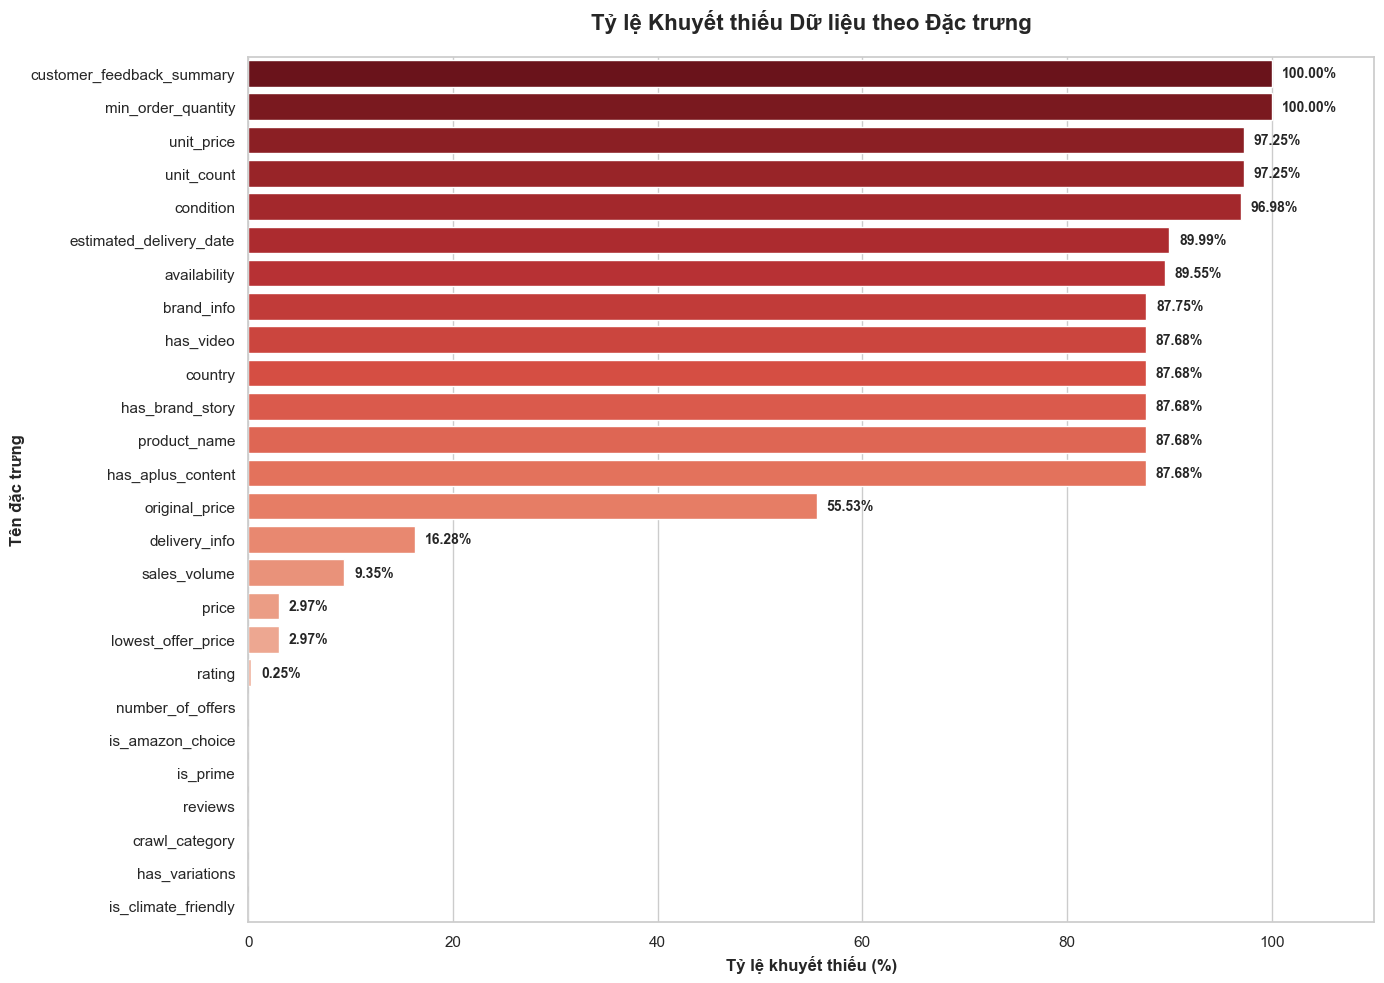

In [16]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

if df_missing_values["Percentage"].dtype == object:
    df_missing_values["Percentage"] = df_missing_values["Percentage"].str.replace("%", "").astype(float)

df_missing_values = df_missing_values.sort_values(by="Percentage", ascending=False)

ax = sns.barplot(
    x="Percentage",
    y="Feature",
    data=df_missing_values,
    palette="Reds_r",
    hue="Feature",
    legend=False
)

plt.title("Tỷ lệ Khuyết thiếu Dữ liệu theo Đặc trưng", 
          fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=12, fontweight="bold")
plt.ylabel("Tên đặc trưng", fontsize=12, fontweight="bold")

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2,
                f"{width:.2f}%", 
                va="center", fontsize=10, fontweight="bold")

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

#### 4.2. Xử lý các đặc trưng khuyết thiếu

**Nhận xét về tình trạng khuyết thiếu dữ liệu:**

Dựa trên bảng thống kê và biểu đồ tỷ lệ khuyết thiếu, chúng ta có thể phân loại tình trạng của tập dữ liệu thành 3 nhóm chính để đưa ra chiến lược xử lý phù hợp:

**Nhóm 1: Nhóm đặc trưng khuyết thiếu nghiêm trọng (85% - 100%)**
- **Tình trạng:** Có tới 13 đặc trưng nằm trong nhóm này. Trong đó, `customer_feedback_summary` và `min_order_quantity` hoàn toàn trống (100%). Các cột khác như `unit_count`, `unit_price`, `condition`, `availability`... cũng có tỷ lệ thiếu hụt trên 90%.
- **Đánh giá:** Lượng dữ liệu thực tế còn lại quá ít (dưới 15%), không đủ để mô hình học máy tìm ra bất kỳ quy luật nào có ý nghĩa.

**Nhóm 2: Nhóm đặc trưng khuyết thiếu trung bình (10% - 56%)**
- **Tình trạng:** `original_price` (55.53%) và `delivery_info` (16.28%).
- **Đánh giá:** Mặc dù tỷ lệ thiếu của `original_price` khá cao, nhưng đây là thông tin quan trọng để tính toán mức độ giảm giá. Chúng ta cần có chiến lược điền giá trị dựa trên logic nghiệp vụ thay vì xóa bỏ.

**Nhóm 3: Nhóm đặc trưng chất lượng tốt (Dưới 10%)**
- **Tình trạng:** Các cột cốt lõi như `price`, `rating`, `reviews`, `sales_volume` và các biến phân loại (`crawl_category`, `is_amazon_choice`...) có tỷ lệ khuyết thiếu rất thấp hoặc bằng 0.
- **Đánh giá:** Đây là nhóm đặc trưng "xương sống", cung cấp nền tảng tin cậy cho việc huấn luyện mô hình.

**Đề xuất xử lý:**

Để đảm bảo mô hình phân tích không bị nhiễu và tập trung vào những thông tin có giá trị thực tế, ta đề xuất xử lý như sau:
- **Loại bỏ toàn bộ các cột có tỷ lệ khuyết thiếu >= 85%:** 
  - **Hành động:** Tiến hành xóa bỏ 13 cột thuộc Nhóm 1.
  - **Lý do:** Việc giữ lại các cột này chỉ làm tăng độ nhiễu và lãng phí tài nguyên tính toán. Việc cố gắng điền giá trị cho hơn 85% dữ liệu trống sẽ tạo ra những giá trị ảo, làm sai lệch hoàn toàn bản chất thực tế của tập dữ liệu.
- **Giữ lại các cột có tỷ lệ thiếu dưới 85%:**
  - **Hành động:** Tiếp tục duy trì các đặc trưng còn lại.
  - **Chiến lược tiếp theo:** Áp dụng logic điền giá trị phù hợp (ví dụ: `original_price` sẽ được điền bằng `price` nếu khuyết thiếu) để tối đa hóa lượng thông tin đưa vào mô hình.

In [17]:
threshold = 85.0

cols_to_drop = df_missing_values[df_missing_values["Percentage"] >= threshold]["Feature"].tolist()

print(f"Số lượng đặc trưng bị loại bỏ (>= {threshold}%): {len(cols_to_drop)}")
print(f"Danh sách các đặc trưng: {cols_to_drop}")

Số lượng đặc trưng bị loại bỏ (>= 85.0%): 13
Danh sách các đặc trưng: ['customer_feedback_summary', 'min_order_quantity', 'unit_price', 'unit_count', 'condition', 'estimated_delivery_date', 'availability', 'brand_info', 'has_video', 'country', 'has_brand_story', 'product_name', 'has_aplus_content']


In [18]:
df = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Kích thước dữ liệu còn lại: {df.shape}")
print(f"Các đặc trưng còn lại: {df.columns.tolist()}")

Kích thước dữ liệu còn lại: (8448, 13)
Các đặc trưng còn lại: ['price', 'original_price', 'rating', 'reviews', 'is_amazon_choice', 'is_prime', 'sales_volume', 'crawl_category', 'delivery_info', 'number_of_offers', 'lowest_offer_price', 'has_variations', 'is_climate_friendly']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8448 entries, 0 to 9179
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                8197 non-null   float64
 1   original_price       3757 non-null   float64
 2   rating               8427 non-null   float64
 3   reviews              8448 non-null   float64
 4   is_amazon_choice     8448 non-null   int64  
 5   is_prime             8448 non-null   int64  
 6   sales_volume         7658 non-null   object 
 7   crawl_category       8448 non-null   object 
 8   delivery_info        7073 non-null   object 
 9   number_of_offers     8448 non-null   int64  
 10  lowest_offer_price   8197 non-null   float64
 11  has_variations       8448 non-null   int64  
 12  is_climate_friendly  8448 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 924.0+ KB


#### 4.3. Xử lý chi tiết các giá trị khuyết thiếu còn lại

Sau khi loại bỏ các đặc trưng quá thưa thớt, chúng ta tiến hành điền giá trị hoặc loại bỏ dòng cho các đặc trưng còn lại. Mục tiêu là tạo ra một bộ dữ liệu đầy đủ, không còn giá trị `NaN`, giúp các thuật toán học máy có thể xử lý được toàn bộ các bản ghi.

**Chiến lược xử lý cho từng đặc trưng:**
- `original_price`: Khoảng 55% sản phẩm thiếu thông tin này. Về mặt nghiệp vụ, điều này có nghĩa là sản phẩm không được giảm giá. Do đó, chúng ta điền `original_price` bằng giá hiện tại (`price`). Điều này giúp duy trì tính nhất quán khi mô hình học về mối quan hệ giữa giá thực tế và giá niêm yết.
- `sales_volume`: Điền giá trị mặc định "0 bought in past month". Việc này đảm bảo khi thực hiện Feature Engineering, các sản phẩm chưa có lượt bán sẽ được định danh chính xác là giá trị 0.
- `delivery_info`: Điền bằng chuỗi mặc định "No delivery information" để xử lý các giá trị khuyết thiếu ở dạng văn bản.
- `price` & `rating`: Đây là các biến số quan trọng nhất (thường là biến mục tiêu hoặc biến tác động mạnh). Vì tỷ lệ thiếu cực thấp (<3%), chúng ta chọn phương pháp loại bỏ các dòng. Điều này giúp loại bỏ hoàn toàn nhiễu và đảm bảo mô hình được huấn luyện trên những dữ liệu thực tế và chính xác nhất.

In [20]:
# 1. Điền giá gốc bằng giá hiện tại
df["original_price"] = df["original_price"].fillna(df["price"])

# 2. Điền giá trị mặc định cho thông tin sản lượng bán
df["sales_volume"] = df["sales_volume"].fillna("0 bought in past month")

# 3. Điền giá trị mặc định cho thông tin giao hàng
df["delivery_info"] = df["delivery_info"].fillna("No delivery information")

# 4. Loại bỏ các bản ghi thiếu các chỉ số cốt lõi (price, rating)
df = df.dropna(subset=["price", "rating"])

# 5. Kiểm tra tổng số lượng giá trị thiếu sau khi xử lý
print("--- Thống kê giá trị khuyết thiếu sau khi xử lý ---")
print(df.isnull().sum())
print(f"Kích thước tập dữ liệu sau khi làm sạch: {df.shape}")

--- Thống kê giá trị khuyết thiếu sau khi xử lý ---
price                  0
original_price         0
rating                 0
reviews                0
is_amazon_choice       0
is_prime               0
sales_volume           0
crawl_category         0
delivery_info          0
number_of_offers       0
lowest_offer_price     0
has_variations         0
is_climate_friendly    0
dtype: int64
Kích thước tập dữ liệu sau khi làm sạch: (8176, 13)


### 5. Feature Engineering

Trong phần này, chúng ta sẽ thực hiện làm giàu dữ liệu bằng cách trích xuất các đặc trưng mới bao gồm (`discount`, `discount_rate`, `sales_volume_num` và `delivery_fee`) từ các cột hiện có. Điều này giúp mô hình học máy nắm bắt được nhiều thông tin hơn từ dữ liệu thô.

#### 5.1. Quan sát mẫu dữ liệu thô trước khi trích xuất

Trước khi Feature Engineering, chúng ta cần quan sát dữ liệu thực tế của các mẫu dữ liệu.

In [21]:
print("--- Mẫu dữ liệu thô của price và original_price ---")
print(df[["price", "original_price"]])
print("--- Mẫu dữ liệu thô của sales_volume ---")
print(df['sales_volume'].unique()[:10])
print("\n--- Mẫu dữ liệu thô của delivery_info ---")
print(df['delivery_info'].unique()[:10])

--- Mẫu dữ liệu thô của price và original_price ---
       price  original_price
1     749.00          749.00
2     799.99          799.99
3      49.99           49.99
4      23.74           24.99
5     369.99          369.99
...      ...             ...
9175   39.00           39.00
9176   39.99           39.99
9177    9.49            9.99
9178   22.96           25.51
9179    9.99            9.99

[8176 rows x 2 columns]
--- Mẫu dữ liệu thô của sales_volume ---
['0 bought in past month' '300+ bought in past month'
 '900+ bought in past month' '4K+ bought in past month'
 '400+ bought in past month' '500+ bought in past month'
 '1K+ bought in past month' '3K+ bought in past month'
 '6K+ bought in past month' 'New on Amazon in past month']

--- Mẫu dữ liệu thô của delivery_info ---
['No delivery information' '$39.09 delivery Apr 8 - 28Ships to Australia'
 '$19.86 delivery Mon, Apr 13Ships to Australia'
 '$17.78 delivery Mon, Apr 13Ships to Australia'
 '$39.09 delivery Tue, Apr 14Ships to 

#### 5.2. Tính toán mức giảm giá (`discount` & `discount_rate`)
Đây là bước quan trọng để xác định mức độ hấp dẫn của giá bán so với giá gốc. Chúng ta sẽ tính toán:
- `discount`: Số tiền được giảm (Giá gốc - Giá hiện tại).
- `discount_rate`: Tỉ lệ phần trăm giảm giá.

In [22]:
df["discount"] = df["original_price"] - df["price"]
df["price"] = df["price"].clip(lower=0)

df["discount_rate"] = np.where(df["original_price"] > 0, df["discount"] / df["original_price"], 0.0)

#### 5.3. Trích xuất sản lượng bán (`sales_volume`)
Chuyển đổi các chuỗi mô tả sản lượng mua hàng hàng tháng (ví dụ: "1K+ bought", "500+ bought") thành các con số có thể tính toán được.

In [23]:
def extract_sales_num(value):
    s = str(value).lower()

    m = re.search(r"(\d+(?:\.\d+)?)\s*([kK]?)\+", s)
    if not m:
        return 0
    num = float(m.group(1))
    if m.group(2) == "k":
        num *= 1000
    return int(num)

In [24]:
df["sales_volume_num"] = df["sales_volume"].apply(extract_sales_num)

#### 5.4. Trích xuất thông tin vận chuyển chi tiết (`delivery_info`)
Chúng ta thực hiện trích xuất giá trị số từ cột `delivery_info` để lấy ra chi phí vận chuyển (`delivery_fee`). Đây là đặc trưng định lượng duy nhất từ dữ liệu giao hàng được giữ lại để đưa vào mô hình.

In [25]:
def extract_delivery_fee(value):
    if pd.isna(value) or str(value).strip() == "" or str(value).lower() == "no delivery information":
        return 0.0
    
    s = str(value).strip()

    m_fee = re.search(r"\$(\d+(?:\.\d+)?)\s*delivery", s, flags=re.IGNORECASE)
    return float(m_fee.group(1)) if m_fee else 0.0

In [26]:
df["delivery_fee"] = df["delivery_info"].apply(extract_delivery_fee)

In [27]:
print("--- Kết quả trích xuất đặc trưng mới ---")
cols_view = ["price", "original_price", "discount", "discount_rate", "sales_volume", "sales_volume_num", "delivery_info", "delivery_fee"]
display(df[cols_view].sample(10))

--- Kết quả trích xuất đặc trưng mới ---


,price,original_price,discount,discount_rate,sales_volume,sales_volume_num,delivery_info,delivery_fee
6598,20.65,28.00,7.35,0.262500,3K+ bought in past month,3000,"$10.89 delivery Mon, Apr 13Ships to Australia",10.89
6980,7.99,7.99,0.00,0.000000,0 bought in past month,0,"$11.53 delivery Mon, Apr 13Ships to Australia",11.53
7858,23.99,23.99,0.00,0.000000,2K+ bought in past month,2000,"$23.70 delivery Mon, Apr 13Ships to Australia",23.70
8557,26.99,29.99,3.00,0.100033,3K+ bought in past month,3000,"$33.86 delivery Mon, Apr 13Ships to Australia",33.86
9172,31.03,34.99,3.96,0.113175,1K+ bought in past month,1000,"$13.12 delivery Friday, April 17 Or fastest de...",13.12
8350,18.99,23.99,5.00,0.208420,9K+ bought in past month,9000,"$20.02 delivery Mon, Apr 13Ships to Australia",20.02
6176,12.26,12.26,0.00,0.000000,10K+ bought in past month,10000,No delivery information,0.00
4716,35.00,35.00,0.00,0.000000,1K+ bought in past month,1000,"$14.34 delivery Mon, Apr 20Ships to Australia",14.34
1350,499.95,499.95,0.00,0.000000,500+ bought in past month,500,"$20.68 delivery Mon, Apr 13Ships to Australia",20.68
3390,55.99,59.99,4.00,0.066678,2K+ bought in past month,2000,"$39.09 delivery Mon, Apr 13Ships to Australia",39.09


In [28]:
df = df.drop(columns=["sales_volume", "delivery_info"])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8176 entries, 1 to 9179
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                8176 non-null   float64
 1   original_price       8176 non-null   float64
 2   rating               8176 non-null   float64
 3   reviews              8176 non-null   float64
 4   is_amazon_choice     8176 non-null   int64  
 5   is_prime             8176 non-null   int64  
 6   crawl_category       8176 non-null   object 
 7   number_of_offers     8176 non-null   int64  
 8   lowest_offer_price   8176 non-null   float64
 9   has_variations       8176 non-null   int64  
 10  is_climate_friendly  8176 non-null   int64  
 11  discount             8176 non-null   float64
 12  discount_rate        8176 non-null   float64
 13  sales_volume_num     8176 non-null   int64  
 14  delivery_fee         8176 non-null   float64
dtypes: float64(8), int64(6), object(1)
memory u

### 6. Chia tách dữ liệu
Để đánh giá mô hình một cách khách quan, chúng ta cần chia tập dữ liệu thành 3 phần:
- **Tập Huấn luyện (Train - 70%):** Dùng để cho mô hình học.
- **Tập Kiểm định (Validation - 15%):** Dùng để tinh chỉnh siêu tham số và tránh Overfitting.
- **Tập Kiểm tra (Test - 15%):** Dùng để đánh giá hiệu năng cuối cùng trên dữ liệu hoàn toàn mới.

In [30]:
input_features = [
    "price", "original_price", "rating", "reviews", 
    "is_prime", "is_amazon_choice", "number_of_offers", 
    "delivery_fee", "is_climate_friendly", "has_variations",
    "discount", "discount_rate",
    "crawl_category",
    "lowest_offer_price"
]

target = "sales_volume_num"
X = df[input_features]
y = df[target]

y_log = np.log1p(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Kích thước tập Train: {X_train.shape} ({len(X_train)/len(df):.0%})")
print(f"Kích thước tập Val:   {X_val.shape} ({len(X_val)/len(df):.0%})")
print(f"Kích thước tập Test:  {X_test.shape} ({len(X_test)/len(df):.0%})")

Kích thước tập Train: (5723, 14) (70%)
Kích thước tập Val:   (1226, 14) (15%)
Kích thước tập Test:  (1227, 14) (15%)


### 7. Biến đổi dữ liệu

#### 7.1. Đặc trưng Số
Quy trình xử lý đối với các đặc trưng số được chia làm 2 nhóm chính dựa trên tính chất phân phối của chúng.

**Các bước xử lý chính:**

**1. Log Transformation (`np.log1p`):** Áp dụng cho các biến bị lệch phải nặng (như `price`, `reviews`). Việc lấy Log giúp thu hẹp khoảng cách giữa các giá trị cực lớn, đưa phân phối về dạng gần chuẩn hơn.

**2. Outlier Clipping (Winsorization):** Giới hạn các giá trị nằm ngoài khoảng Percentile 1% và 99%. Bước này giúp loại bỏ nhiễu từ các giá trị quá dị biệt mà không cần xóa bỏ dữ liệu.

**3. Standardization (StandardScaler):** Đưa tất cả các biến về cùng một thang đo với trung bình (Mean) = 0 và độ lệch chuẩn (Std) = 1. Điều này giúp các thuật toán tối ưu hóa (như Gradient Descent) hội tụ nhanh hơn.

In [31]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """Xử lý Outlier bằng cách Clip giá trị tại Percentile 1% và 99%"""
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
    def fit(self, X, y=None):
        self.lower_thresholds_ = X.quantile(self.lower_quantile)
        self.upper_thresholds_ = X.quantile(self.upper_quantile)
        return self
    def transform(self, X):
        return X.clip(lower=self.lower_thresholds_, upper=self.upper_thresholds_, axis=1)

In [32]:
skewed_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('clipper', OutlierClipper(lower_quantile=0.01, upper_quantile=0.99)),
    ('scaler', StandardScaler())
])

stable_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

#### 7.2. Đặc trưng Boolean & Categorical

**Các bước xử lý:**

**1. Categorical Features (`OneHotEncoder`):** Đối với biến `crawl_category`, chúng ta sử dụng kỹ thuật One-Hot Encoding để tạo ra các cột định danh (0/1) cho từng danh mục sản phẩm.
- **Lưu ý:** Sử dụng tham số `handle_unknown='ignore'` để đảm bảo Pipeline không bị lỗi khi gặp một danh mục mới chưa từng xuất hiện trong tập huấn luyện.

**2. Boolean Features (Passthrough):** Các biến như `is_prime`, `is_amazon_choice`... hiện đã được chúng ta chuyển về dạng số nguyên (0 và 1) ở bước tiền xử lý thô. Do đó, chúng ta chỉ cần cho phép chúng đi qua Pipeline (`passthrough`) mà không cần biến đổi thêm.

In [33]:
categorical_features = ['crawl_category']
boolean_features = ['is_prime', 'is_amazon_choice', 'is_climate_friendly', 'has_variations']

In [34]:
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

boolean_pipeline = Pipeline([
    ('identity', 'passthrough')
])

#### 7.3. Xây dựng Pipeline hoàn chỉnh

In [35]:
categorical_cols = ['crawl_category']
boolean_cols = ['is_prime', 'is_amazon_choice', 'is_climate_friendly', 'has_variations']
skewed_cols = ['price', 'original_price', 'reviews', 'number_of_offers', 'delivery_fee', 'discount', 'lowest_offer_price']
stable_cols = ['rating', 'discount_rate']

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_path', skewed_pipeline, skewed_cols),
        ('stable_path', stable_pipeline, stable_cols),
        ('cat_path', categorical_pipeline, categorical_cols),
        ('bool_path', boolean_pipeline, boolean_cols)
    ]
)

In [37]:
modeling_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

### 8. Thực thi Pipeline trên các tập dữ liệu
Ở bước này, chúng ta sẽ áp dụng các quy tắc đã định nghĩa trong Pipeline vào thực tế.

**Lưu ý cực kỳ quan trọng:** Chúng ta sử dụng `.fit_transform()` trên tập **Train** (để Pipeline học các thông số như Mean, Std, Quantile). Sau đó, chúng ta chỉ dùng `.transform()` trên tập **Val** và **Test** để đảm bảo tính khách quan (không rò rỉ thông tin từ tập Test vào mô hình).

In [38]:
X_train_prepared = modeling_pipeline.fit_transform(X_train)
X_val_prepared = modeling_pipeline.transform(X_val)
X_test_prepared = modeling_pipeline.transform(X_test)

In [39]:
print(f"Kích thước X_train sau Pipeline: {X_train_prepared.shape}")
print(f"Kích thước X_val sau Pipeline:   {X_val_prepared.shape}")
print(f"Kích thước X_test sau Pipeline:  {X_test_prepared.shape}")

Kích thước X_train sau Pipeline: (5723, 43)
Kích thước X_val sau Pipeline:   (1226, 43)
Kích thước X_test sau Pipeline:  (1227, 43)


In [40]:
print("\nMẫu dữ liệu sau khi xử lý:")
print(X_train_prepared[:5])


Mẫu dữ liệu sau khi xử lý:
[[-0.50124288 -0.21175314 -0.0887139  -0.51700978  0.26297208  1.06958325
  -0.47613516 -0.17550805  1.91476568  0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [ 1.30651028  1.80299131 -0.35738687 -0.51700978  0.83717798  2.78118813
   1.37089949 -0.17550805  2.87856701  0.          0.          0.
   0.          0.          0.          0.          0.          0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [

### 9. Lưu trữ dữ liệu và Pipeline
Sau khi đã tiền xử lý thành công, chúng ta cần lưu lại hai thứ quan trọng:

**1. Bộ Pipeline (`modeling_pipeline`):** Để có thể tái sử dụng cho việc dự báo dữ liệu mới mà không cần thiết lập lại các tham số (Mean, Std, Categories).

**2. Dữ liệu đã xử lý (Train/Val/Test):** Để có thể tải nhanh vào các mô hình học máy khác nhau trong bước tiếp theo.

In [41]:
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

In [42]:
pipeline_filename = f"{output_dir}/sales_prediction_pipeline.joblib"
joblib.dump(modeling_pipeline, pipeline_filename)
print(f"Đã lưu Pipeline tại: {pipeline_filename}")

Đã lưu Pipeline tại: ../data/processed/sales_prediction_pipeline.joblib


In [43]:
train_df = pd.DataFrame(X_train_prepared)
train_df['target_log'] = y_train.values
train_df.to_csv(f"{output_dir}/train.csv", index=False)

val_df = pd.DataFrame(X_val_prepared)
val_df['target_log'] = y_val.values
val_df.to_csv(f"{output_dir}/val.csv", index=False)

test_df = pd.DataFrame(X_test_prepared)
test_df['target_log'] = y_test.values
test_df.to_csv(f"{output_dir}/test.csv", index=False)

print(f"Đã lưu các tập dữ liệu Train/Val/Test tại: {output_dir}")

Đã lưu các tập dữ liệu Train/Val/Test tại: ../data/processed
